# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

-city: 11.7% de nulos, se debe investigar o imputar.

-churn_date: 88.3% de nulos, se ignora, es un dato normal (usuario aún activo, sin fecha de cancelación).

-date: 0.1% de nulos, no afecta el análisis.

-duration y length: 55.2% y 44.7% de nulos respectivamente, son esperados porque cada fila de usage corresponde a un tipo de registro distinto (llamada o mensaje).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` : El rango (10,000-13,999) es coherente con las 4000 filas, sin valores negativos ni fuera de lo esperado.
- La columna `age` : El valor mínimo es -999, lo cual es imposible para una edad real. Esto sugiere que es un valor centinela usado para marcar datos faltantes o inválidos, no una edad verdadera.

In [13]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: En id el min y max se marcan coherentemente al numero de usurios existentes, y el user_id el rango (10,000-13,999) es coherente con las 4000 filas, sin valores negativos ni fuera de lo esperado.
- Las columnas `duration` y `length`: tienen valores máximos razonables para llamadas y mensajes de texto respectivamente, sin valores atípicos evidentes.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user: 
    print (users[col].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` Tiene valores nulos (NaN). Además, tiene 96 registros con el valor "?", que parece ser otra forma de indicar ciudad desconocida (no un valor de ciudad real).
- La columna `plan` Los valores son razonables, la suma de plan basico y plan premium dan el total de usuarios (2595 + 1405 = 4000)

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no cuenta con valores raros ni nulos aparentes, si suman las cantidades dan un resultado razonable que coincide con el total de registros  (22092 + 17908 = 40000)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
¿En qué columnas encontraste valores inválidos o sentinels?  
¿Qué acción tomarías?

La columna **age** se encontro un sentinel -999, reemplazar por la mediana. 
la columna **city** se encontro un valor inválido "?", reemplazar por una etiqueta como "sin dato".

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.describe()

count    4000.000000
mean     2023.034000
std         0.866044
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2026.000000
Name: reg_date, dtype: float64

En `reg_date`,  se realizo la conversion a fecha correctamente, al revisar los años de registro, la mayoría se concentra en 2022-2024. se detecto que hay una pequeña cantidad (40) con año 2026, lo cual parece un error puntual y no afecta significativamente el análisis general.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.describe()

count    39950.0
mean      2024.0
std          0.0
min       2024.0
25%       2024.0
50%       2024.0
75%       2024.0
max       2024.0
Name: date, dtype: float64

En `date`, no aparecen años imposibles, todas las fechas corresponden a 2024, por lo que no se requiere ninguna corrección.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En **reg_date**, se realizo la conversion a fecha correctamente, al revisar los años de registro, la mayoría se concentra en 2022-2024. se detecto que hay una pequeña cantidad (40) con año 2026, lo cual parece un error puntual y no afecta significativamente el análisis general por lo que se dejaría así. y En **date**, no aparecen años imposibles, todas las fechas corresponden a 2024, por lo que no se requiere ninguna corrección.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
hoy = pd.to_datetime('2024')
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].max()

Timestamp('2024-01-01 00:00:00')

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isnull()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isnull()]['type'].value_counts()

call    17896
Name: type, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
- **duration** es nulo cuando type = 'text' (un mensaje de texto no tiene duración).
- **length** es nulo cuando type = 'call' (una llamada no tiene "longitud" de datos).

---
## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'length']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,length
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [26]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','length': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,288.128032
std,17.691541,2.358416,2.144238,180.906841
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,184.000000
50%,48.000000,5.000000,4.000000,268.000000
75%,63.000000,7.000000,6.000000,361.000000
max,79.000000,17.000000,15.000000,2028.000000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

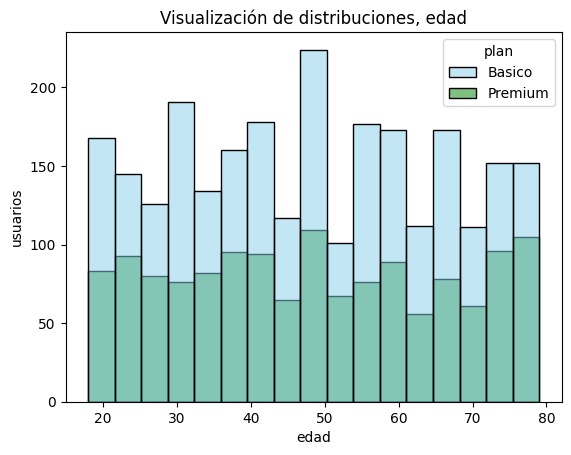

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Visualización de distribuciones, edad')
plt.xlabel('edad')
plt.ylabel('usuarios')
plt.show()

💡Insights: 
- Distribución del plan basico predomina en la mayoria de los rangos de edad, como por ejemplo en la edad 50 el basico es mas alto que premium, pero en las edades 20, 40 y 60 los planes estan bastantes parejos.

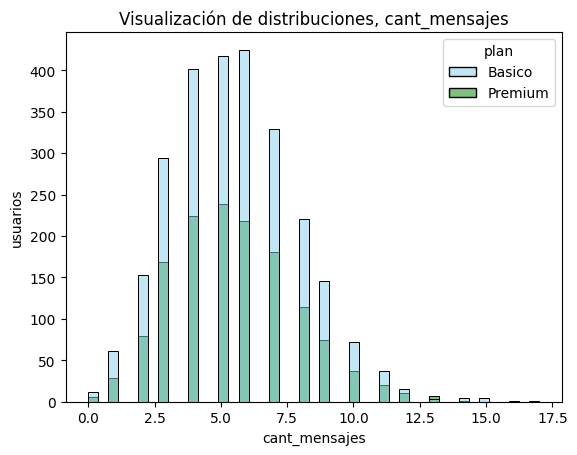

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Visualización de distribuciones, cant_mensajes')
plt.xlabel('cant_mensajes')
plt.ylabel('usuarios')
plt.show()

💡Insights: 
- La visualización de distribuciones, el rango de valores se concentra del 2.5 al 7.5, por lo que la distribución se inclina a la derecha, en los planes la distribución esta pareja pero el básico toma un poco de ventaja.

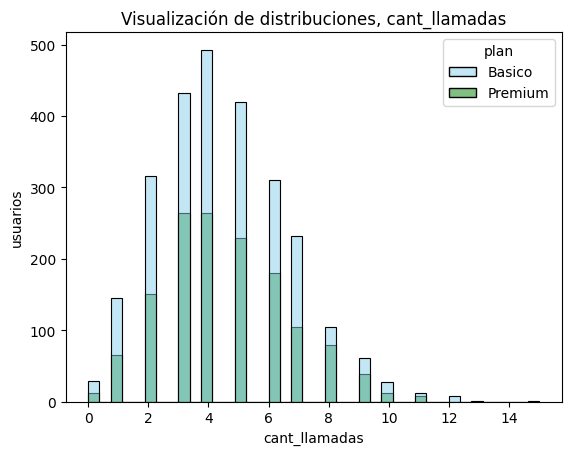

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Visualización de distribuciones, cant_llamadas')
plt.xlabel('cant_llamadas')
plt.ylabel('usuarios')
plt.show()


💡Insights: 
- Distribución el rango de valores se concentra del 2 al 6, por lo que la distribución se inclina a la derecha, en los planes la distribución esta pareja pero el básico toma un poco de ventaja

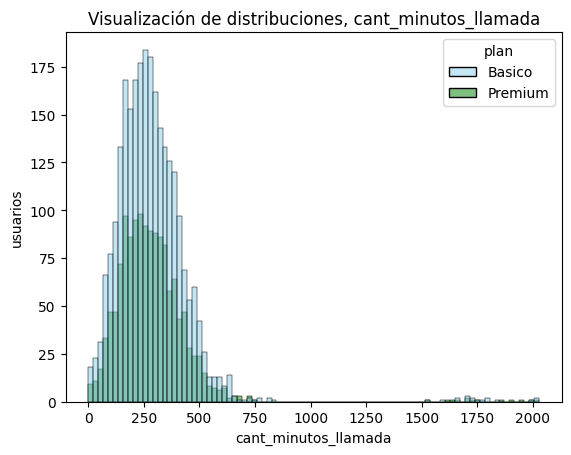

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Visualización de distribuciones, cant_minutos_llamada')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('usuarios')
plt.show()


💡Insights: 
- LA distribución el rango de valores se concentra del 100 al 400, por lo que la distribución se inclina a la derecha y cuenta con valores aislados cerca de 1500-2000 (posibles outliers), en los planes la distribución el básico toma ventaja.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:** 
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

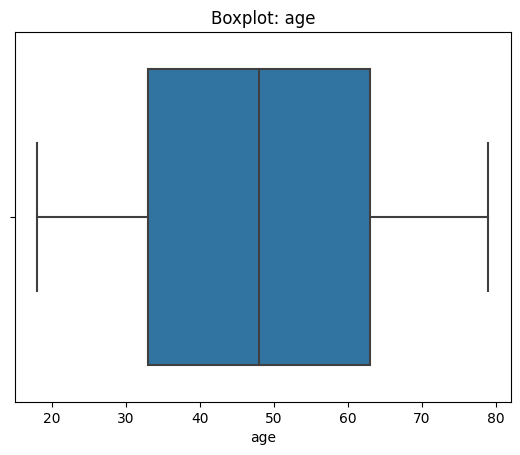

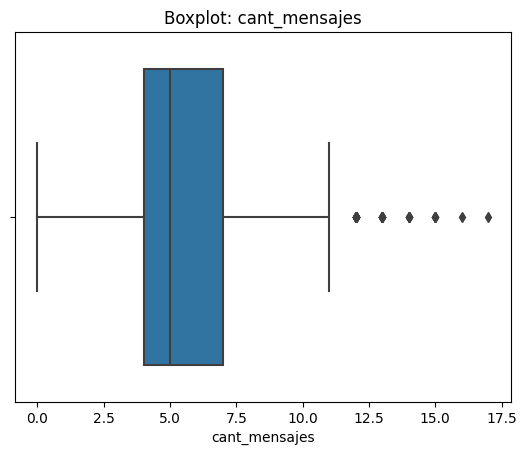

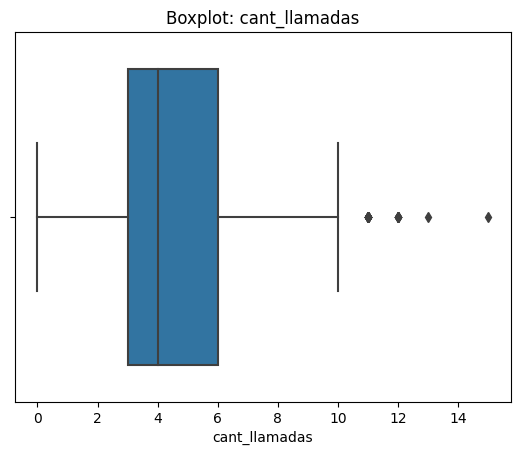

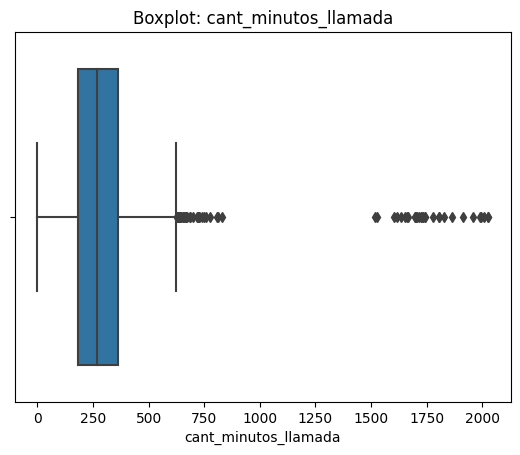

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers): la edad se concentra en un rango normal (más o menos entre 33 y 63 años, con mediana alrededor de 48) y no hay outliers visibles en los bigotes.
- cant_mensajes: el rango de valores que tiene la mayoría de usuarios es de 0 a 11 la mayoría usa de 4 a 7 aprox. y de entre 12 y 17 mensajes aprox. son outliers: usuarios que mandan más mensajes
- cant_llamadas: el rango de valores que tiene la mayoría de usuarios es de 0 a 10 la mayoría usa de 3 a 6 aprox. y de entre 11 y 15 aprox. son outliers: usuarios que hacen mas llamadas
- cant_minutos_llamada: el rango de valores que tiene la mayoría de usuarios es de 0 a 600 la mayoría usa de 200 a 300 aprox. y de entre 700 y 850 aprox. son outliers como también de 1500 a 2000: usuarios que salen del rango.

In [35]:
# Calcular límites con el método IQR
columnas_limites =  ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)
    IQR = Q3 - Q1
    print('IQR: ', IQR)
    limite_inferior = Q1 - 1.5*IQR
    print('limite_inferior: ', limite_inferior)
    limite_superior = Q3 + 1.5*IQR
    print('limite_superior: ', limite_superior)

Primer cuartil:  33.0
Tercer cuartil:  63.0
IQR:  30.0
limite_inferior:  -12.0
limite_superior:  108.0
Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
limite_inferior:  -0.5
limite_superior:  11.5
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
limite_inferior:  -1.5
limite_superior:  10.5
Primer cuartil:  184.0
Tercer cuartil:  361.0
IQR:  177.0
limite_inferior:  -81.5
limite_superior:  626.5


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,288.128032
std,17.691541,2.358416,2.144238,180.906841
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,184.000000
50%,48.000000,5.000000,4.000000,268.000000
75%,63.000000,7.000000,6.000000,361.000000
max,79.000000,17.000000,15.000000,2028.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? mantener los outliers porque las diferencias son pequeñas, son valores normales dentro del comportamiento de los usuarios, no errores ni casos extremos que requieran tratamiento especial.
- cant_llamadas: mantener o no outliers, porqué? mantener los outliers porque representan usuarios reales con un comportamiento distinto (los "power users"), no errores de carga de datos. Eliminarlos haría perder información valiosa sobre ese segmento de clientes.
- cant_minutos_llamada: mantener o no outliers, porqué? mantener los outliers porque las diferencias son pequeñas, son valores normales dentro del comportamiento de los usuarios, no errores ni casos extremos que requieran tratamiento especial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def grupo_uso (llamadas, mensajes) :
    if llamadas< 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas< 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto Uso'

print(grupo_uso(5, 5))   
print(grupo_uso(10, 10))  
print(grupo_uso(30, 30))
user_profile['grupo_uso'] = user_profile.apply(lambda row: grupo_uso(row['cant_llamadas'], row['cant_mensajes']), axis=1)

Uso medio
Alto Uso
Alto Uso


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,258.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,226.0,Alto Uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,530.0,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def grupo_edad (age) :
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

print(grupo_edad (30))   
print(grupo_edad (60))  
print(grupo_edad (70))
user_profile['grupo_edad'] = user_profile.apply(lambda row: grupo_edad(row['age']), axis=1)

Adulto
Adulto Mayor
Adulto Mayor


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,226.0,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,530.0,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

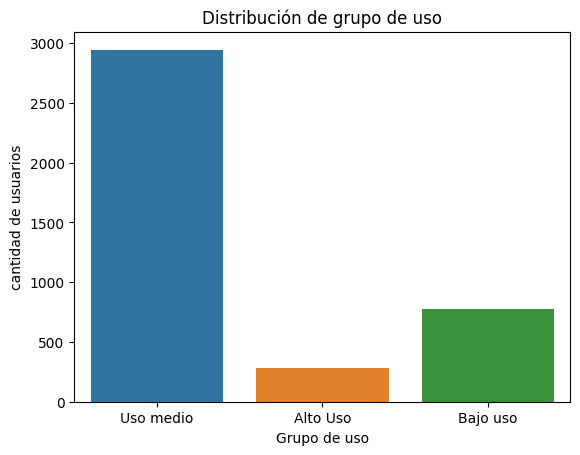

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('cantidad de usuarios')
plt.show()

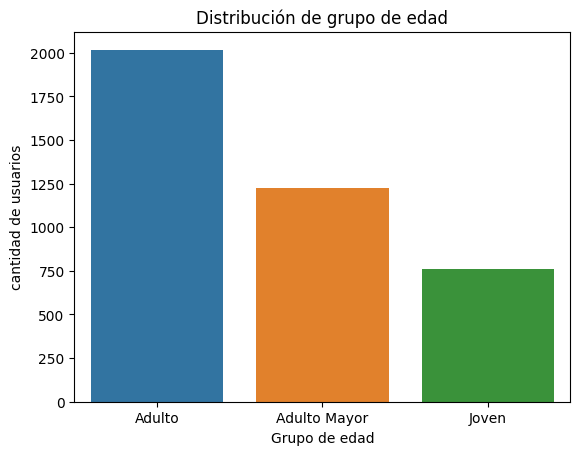

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

La columna **city** contaba con 11.7% de nulos (96 registros con valor "?") parecia ser otra forma de indicar ciudad desconocida (no un valor de ciudad real).Lo cual el valor invalido se reemplazo por una etiqueta como "sin dato", **churn_date** 88.3% de nulos, se ignoro ya que era un dato normal (usuario aún activo, sin fecha de cancelación), **date** 0.1% de nulos, no afecta el análisis, **duration** y **length** 55.2% y 44.7% de nulos respectivamente, son esperados porque cada fila de usage corresponde a un tipo de registro distinto (llamada o mensaje).


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

En la categoría **grupo edad** el grupo de edad más numeroso es **Adulto** con 2000 usuarios, seguido por el grupo **Adulto mayor** con 1,250 usuarios y ultimo el grupo **Joven** con 750 usuarios, en la distribución de **grupo uso** se observa que predomina el **uso medio** en llamadas y mensajes con 2,900 usuarios, el mas bajo con 300 usuarios es **alto uso** y con 700 de usuarios el **bajo uso**.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El grupo de **Alto uso** genera más ingresos por cliente aunque sean pocos, mientras **Uso medio** aporta estabilidad por ser la mayoría.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

En las columnas donde se encontraron los outliers fueron en minutos de llamada, mensajes, datos, duración:
mensajes: el rango de valores que tienen los usuarios es de 0 a 11, la mayoría usa de 4 a 7 aprox. y de entre 12 y 17 mensajes aprox. son outliers son los usuarios que mandan más mensajes, llamadas: el rango de valores que tienen los usuarios es de 0 a 10, la mayoría usa de 3 a 6 aprox. y de entre 11 y 15 aprox. son outliers son los usuarios que mandan más llamadas,
minutos llamada: el rango de valores que tienen los usuarios es de 0 a 600, la mayoría usa de 200 a 300 aprox. y de entre 700 y 850 aprox. son outliers como también de 1500 a 2000 usuarios que salen del rango. 

Un cliente con un uso extremadamente alto de mensajes o llamadas podría ser un usuario corporativo o alguien que indispensablemente tiene que estar conectado en llamadas y mensajes, se les podría investigar un poco mas para ver que tanto mas consumen y ofrecer un plan mas acorde a sus necesidades.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Para el grupo de alto uso son pocas los usuarios que lo consumen pero consumen mucho, convendría el plan premium, en el grupo de uso medio son la mayoría de usuarios aquí los que están dentro del rango del grupo de uso medio sería asignar en plan básico, para los outliers se les podría investigar un poco mas para ver que tanto mas consumen y ofrecer un plan mas acorde a sus necesidades.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna **city** contaba con 11.7% de nulos (96 registros con valor "?") parecia ser otra forma de indicar ciudad desconocida (no un valor de ciudad real).Lo cual el valor invalido se reemplazo por una etiqueta como "sin dato"
-  La columna **churn_date** 88.3% de nulos, se ignoro ya que era un dato normal (usuario aún activo, sin fecha de cancelación)
-  La columna **date** 0.1% de nulos, no afecta el análisis.
- La columna **duration** y **length** 55.2% y 44.7% de nulos respectivamente, son esperados porque cada fila de usage corresponde a un tipo de registro distinto (llamada o mensaje).


🔍 **Segmentos por Edad**
- En la categoría **grupo edad** el grupo de edad más numeroso es **Adulto** con 2000 usuarios.
- Seguido por el grupo **Adulto mayor** con 1,250 usuarios.
- Ultimo el grupo **Joven** con 750 usuarios.


📊 **Segmentos por Nivel de Uso**
- En la distribución de **grupo uso** se observa que predomina el **uso medio** en llamadas y mensajes con 2,900 usuarios, el mas bajo con 300 usuarios es **alto uso** y con 700 de usuarios el **bajo uso**.
- El grupo de **Alto uso** genera más ingresos por cliente aunque sean pocos, mientras **Uso medio** aporta estabilidad por ser la mayoría.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Para el grupo de alto uso son pocas los usuarios que lo consumen pero consumen mucho, convendría el plan premium.
- en el grupo de uso medio son la mayoría de usuarios aquí los que están dentro del rango del grupo de uso medio sería asignar en plan básico.
- Para los outliers se les podría investigar un poco mas para ver que tanto mas consumen y ofrecer un plan mas acorde a sus necesidades.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`